In [6]:
ls food-101\images

 Volume in drive E is problem
 Volume Serial Number is DEEC-2CEE

 Directory of E:\JupyTerONvsCode\food-101\images

05/06/2024  07:12 PM    <DIR>          .
05/06/2024  07:15 PM    <DIR>          ..
05/06/2024  07:12 PM    <DIR>          beef_pettie
05/06/2024  07:12 PM    <DIR>          hard_bread_bun
05/06/2024  07:12 PM    <DIR>          lettuce_leaves
05/06/2024  07:12 PM    <DIR>          tomato_slices
               0 File(s)              0 bytes
               6 Dir(s)  166,198,497,280 bytes free


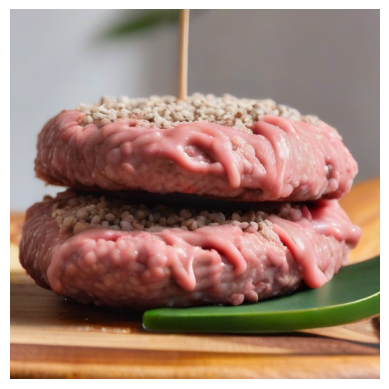

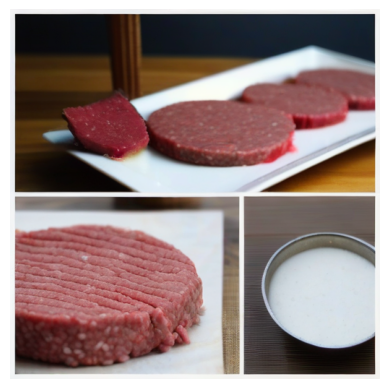

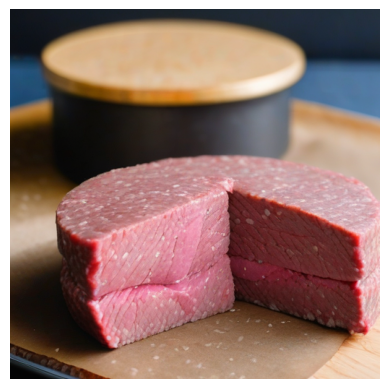

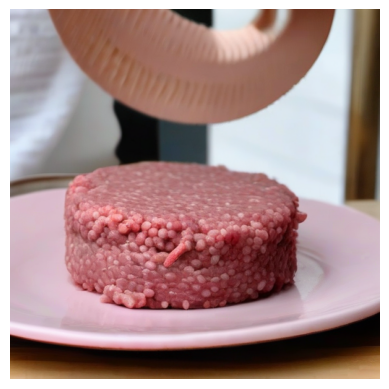

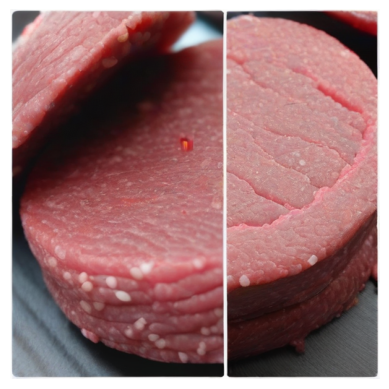

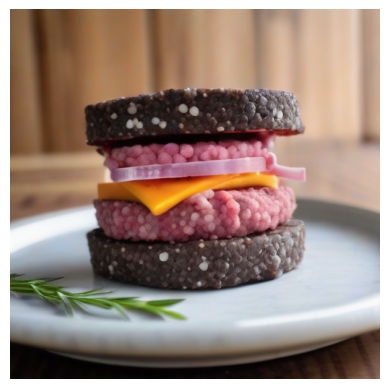

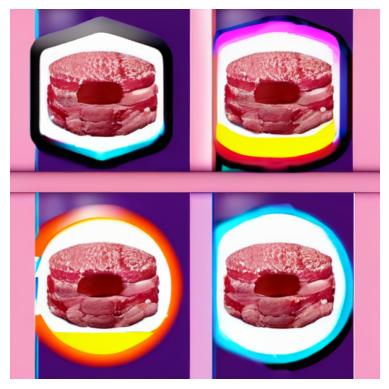

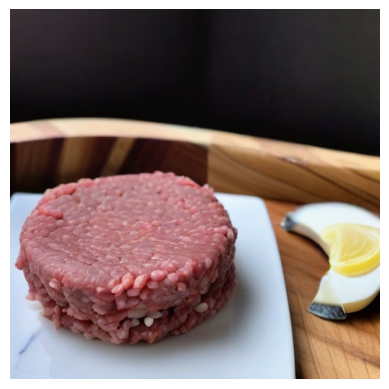

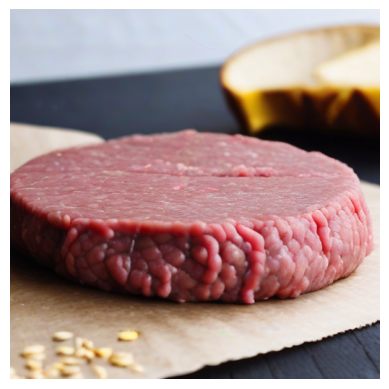

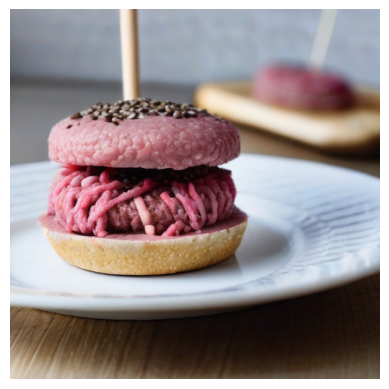

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

directory = 'food-101/images/beef_pettie/'

# List files in the directory
files = os.listdir(directory)

# Display the first 10 images
for file in files[:10]:
    image_path = os.path.join(directory, file)
    image = mpimg.imread(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

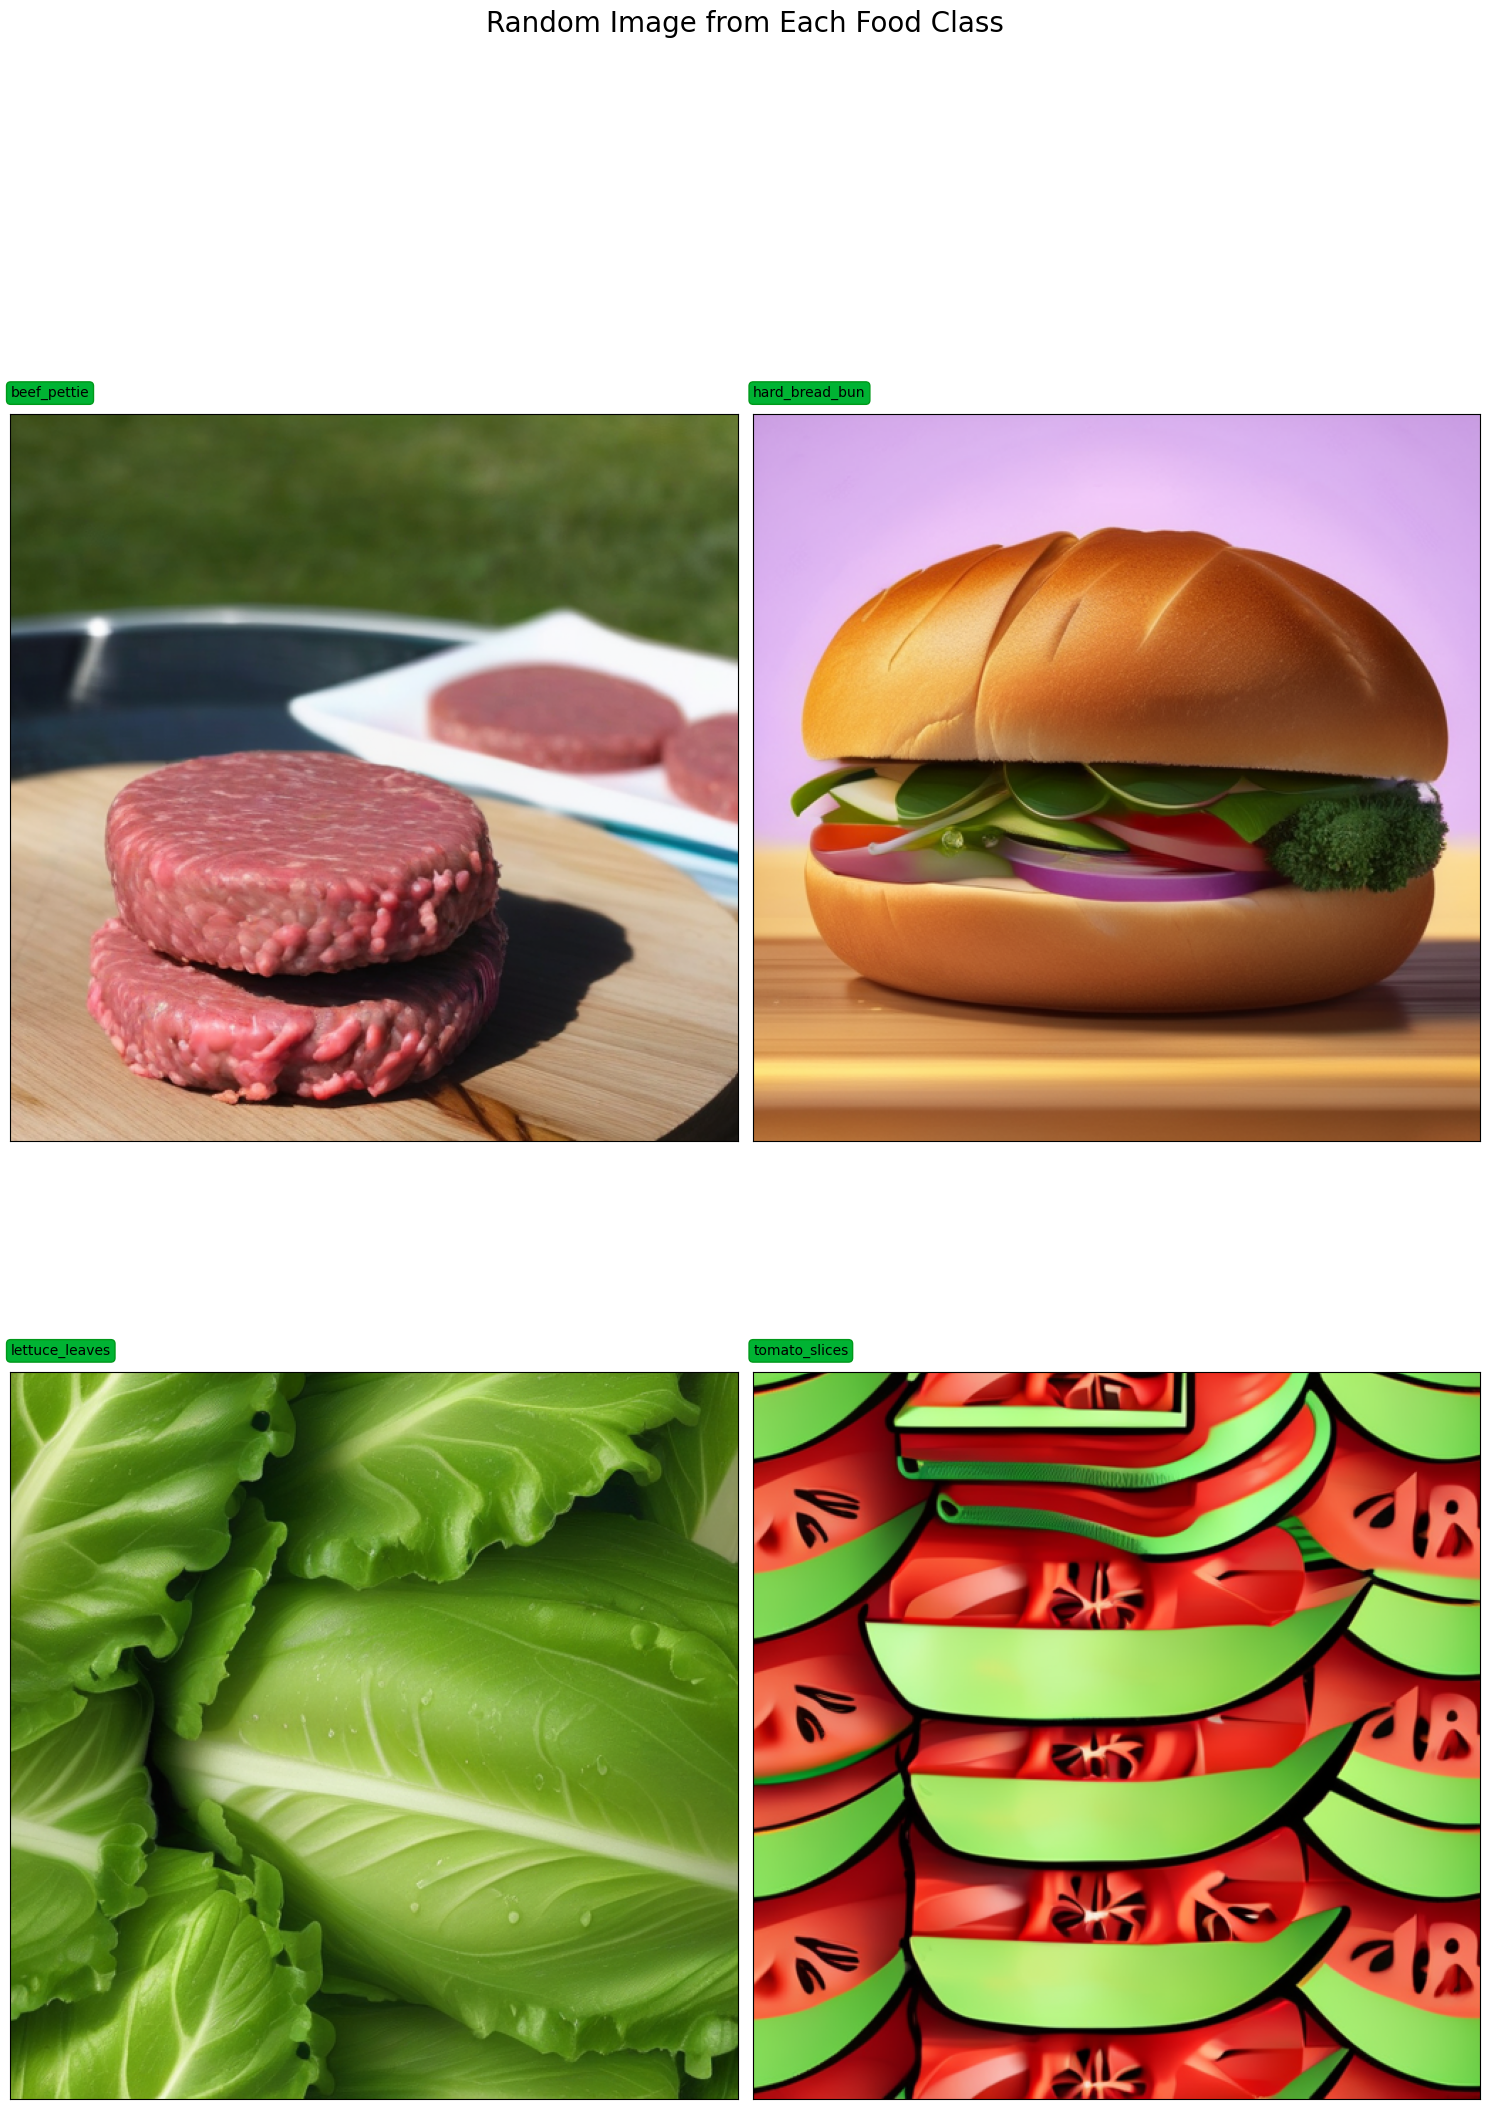

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

root_dir = 'food-101/images/'

# Get the list of food directories
food_dirs = sorted(os.listdir(root_dir))

# Calculate the number of rows and columns dynamically
num_classes = len(food_dirs)
num_cols = int(np.ceil(np.sqrt(num_classes)))
num_rows = int(np.ceil(num_classes / num_cols))

# Create subplots
fig, ax = plt.subplots(num_rows, num_cols, frameon=False, figsize=(15, 25))
fig.suptitle('Random Image from Each Food Class', fontsize=20)

# Plot images for each class
for i, food_dir in enumerate(food_dirs):
    row_idx = i // num_cols
    col_idx = i % num_cols
    
    all_files = os.listdir(os.path.join(root_dir, food_dir))
    rand_img = np.random.choice(all_files)
    img = plt.imread(os.path.join(root_dir, food_dir, rand_img))
    ax[row_idx][col_idx].imshow(img)
    ec = (0, .6, .1)
    fc = (0, .7, .2)
    ax[row_idx][col_idx].text(0, -20, food_dir, size=10, rotation=0,
                              ha="left", va="top", 
                              bbox=dict(boxstyle="round", ec=ec, fc=fc))

# Hide ticks
plt.setp(ax, xticks=[], yticks=[])

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()


In [9]:
# Setup multiprocessing pool
# Do this early, as once images are loaded into memory there will be Errno 12
# http://stackoverflow.com/questions/14749897/python-multiprocessing-memory-usage
import multiprocessing as mp

num_processes = 6
pool = mp.Pool(processes=num_processes)

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import collections  # Import collections module

class_to_ix = {}
ix_to_class = {}
with open('food-101/meta/classes.txt', 'r') as txt:
    classes = [l.strip() for l in txt.readlines()]
    class_to_ix = dict(zip(classes, range(len(classes))))
    ix_to_class = dict(zip(range(len(classes)), classes))
    class_to_ix = {v: k for k, v in ix_to_class.items()}
    sorted_class_to_ix = collections.OrderedDict(sorted(class_to_ix.items()))  # Ensure 'collections' is used


In [11]:
import os
import shutil
import stat
from collections import defaultdict

# Only split files if haven't already
if not os.path.isdir('./food-101/test') and not os.path.isdir('./food-101/train'):

    def copytree(src, dst, symlinks=False, ignore=None):
        # Your existing copytree function implementation
        if not os.path.exists(dst):
            os.makedirs(dst)
            shutil.copystat(src, dst)
        lst = os.listdir(src)
        if ignore:
            excl = ignore(src, lst)
            lst = [x for x in lst if x not in excl]
        for item in lst:
            s = os.path.join(src, item)
            d = os.path.join(dst, item)
            if symlinks and os.path.islink(s):
                if os.path.lexists(d):
                    os.remove(d)
                os.symlink(os.readlink(s), d)
                try:
                    st = os.lstat(s)
                    mode = stat.S_IMODE(st.st_mode)
                    os.lchmod(d, mode)
                except:
                    pass # lchmod not available
            elif os.path.isdir(s):
                copytree(s, d, symlinks, ignore)
            else:
                shutil.copy2(s, d)

    def generate_dir_file_map(path):
        # Your existing generate_dir_file_map function implementation
        dir_files = defaultdict(list)
        with open(path, 'r') as txt:
            files = [l.strip() for l in txt.readlines()]
            for f in files:
                dir_name, id = f.split('/')
                dir_files[dir_name].append(id + '.jpg')
        return dir_files

    train_dir_files = generate_dir_file_map('food-101/meta/train.txt')
    test_dir_files = generate_dir_file_map('food-101/meta/test.txt')

    def ignore_train(d, filenames):
        # Your existing ignore_train function implementation
        print(d)
        subdir = d.split('/')[-1]
        to_ignore = train_dir_files[subdir]
        return to_ignore

    def ignore_test(d, filenames):
        # Your existing ignore_test function implementation
        print(d)
        subdir = d.split('/')[-1]
        to_ignore = test_dir_files[subdir]
        return to_ignore

    copytree('food-101/images', 'food-101/test', ignore=ignore_train)
    copytree('food-101/images', 'food-101/train', ignore=ignore_test)
    
else:
    print('Train/Test files already copied into separate folders.')


Train/Test files already copied into separate folders.


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img
from skimage.transform import resize
from collections import defaultdict

# Function to generate class indices based on directory names
def generate_class_indices(root):
    class_to_ix = {}
    ix_to_class = {}
    for i, subdir in enumerate(os.listdir(root)):
        class_to_ix[subdir] = i
        ix_to_class[i] = subdir
    return class_to_ix, ix_to_class

# Load dataset images and resize to meet minimum width and height pixel size
def load_images(root, class_to_ix, min_side=299):
    all_imgs = []
    all_classes = []
    resize_count = 0
    invalid_count = 0
    for i, subdir in enumerate(os.listdir(root)):
        imgs = os.listdir(os.path.join(root, subdir))
        class_ix = class_to_ix[subdir]
        print(i, class_ix, subdir)
        for img_name in imgs:
            img_arr = img.imread(os.path.join(root, subdir, img_name))
            img_arr_rs = img_arr
            try:
                w, h, _ = img_arr.shape
                if w < min_side:
                    wpercent = (min_side/float(w))
                    hsize = int((float(h)*float(wpercent)))
                    img_arr_rs = resize(img_arr, (min_side, hsize))
                    resize_count += 1
                elif h < min_side:
                    hpercent = (min_side/float(h))
                    wsize = int((float(w)*float(hpercent)))
                    img_arr_rs = resize(img_arr, (wsize, min_side))
                    resize_count += 1
                all_imgs.append(img_arr_rs)
                all_classes.append(class_ix)
            except:
                print('Skipping bad image: ', subdir, img_name)
                invalid_count += 1
    print(len(all_imgs), 'images loaded')
    print(resize_count, 'images resized')
    print(invalid_count, 'images skipped')
    return np.array(all_imgs), np.array(all_classes)

# Generate class indices
root_dir = 'food-101/test'  # Change this to your dataset directory
class_to_ix, ix_to_class = generate_class_indices(root_dir)

# Load images
X_test, y_test = load_images(root_dir, class_to_ix, min_side=299)


0 0 beef_pettie
1 1 hard_bread_bun
2 2 lettuce_leaves
3 3 tomato_slices
222 images loaded
0 images resized
0 images skipped


In [13]:
%%time
# Load training set images
X_train, y_train = load_images('food-101/train', class_to_ix, min_side=299)


0 0 beef_pettie
1 1 hard_bread_bun
2 2 lettuce_leaves
3 3 tomato_slices
222 images loaded
0 images resized
0 images skipped
CPU times: total: 453 ms
Wall time: 2.89 s


In [14]:
print('X_train shape', X_train.shape)
print('y_train shape', y_train.shape)
print('X_test shape', X_test.shape)
print('y_test shape', y_test.shape)

X_train shape (222, 512, 512, 3)
y_train shape (222,)
X_test shape (222, 512, 512, 3)
y_test shape (222,)


In [15]:
from ipywidgets import interact

@interact(n=(0, len(X_train)))
def show_pic(n):
    plt.imshow(X_train[n])
    print('class:', y_train[n], ix_to_class[y_train[n]])


interactive(children=(IntSlider(value=111, description='n', max=222), Output()), _dom_classes=('widget-interac…

In [16]:
sorted_class_to_ix = sorted(class_to_ix.items(), key=lambda x: x[0])

@interact(n_class=sorted_class_to_ix)
def show_random_images_of_class(n_class=0):
    print(n_class)
    nrows = 4
    ncols = 8
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
    fig.set_size_inches(12, 8)
    #fig.tight_layout()
    imgs = np.random.choice((y_train == n_class).nonzero()[0], nrows * ncols)
    for i, ax in enumerate(axes.flat):
        im = ax.imshow(X_train[imgs[i]])
        ax.set_axis_off()
        ax.title.set_visible(False)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    plt.subplots_adjust(left=0, wspace=0, hspace=0)
    plt.show()


interactive(children=(Dropdown(description='n_class', options=(('beef_pettie', 0), ('hard_bread_bun', 1), ('le…

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set the paths to your training and testing datasets
train_data_dir = 'food-101/train'
test_data_dir = 'food-101/test'

# Define image dimensions and other parameters
img_width, img_height = 224, 224
batch_size = 32
num_epochs = 3

def load_images(directory):
    images = []
    labels = []
    for label, class_name in enumerate(os.listdir(directory)):
        class_dir = os.path.join(directory, class_name)
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            try:
                image = Image.open(image_path).resize((img_width, img_height))
                image = np.array(image) / 255.0  # Rescale image to [0, 1]
                images.append(image)
                labels.append(label)
            except Exception as e:
                print(f"Error loading image: {image_path}, {e}")
    return np.array(images), np.array(labels)

# Load training and testing images
X_train, y_train = load_images(train_data_dir)
X_test, y_test = load_images(test_data_dir)

In [21]:
# Define the model architecture
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(len(np.unique(y_train)), activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test))

# Save the trained model to a file
model.save('food_classification_model.h5')


# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# Perform image classification
def classify_image(image_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image) / 255.0  # Rescale image to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    prediction = model.predict(image)
    class_idx = np.argmax(prediction)
    return class_idx


Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - accuracy: 0.3015 - loss: 2.3582 - val_accuracy: 0.4505 - val_loss: 1.1547
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.4302 - loss: 1.1327 - val_accuracy: 0.6486 - val_loss: 0.8346
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 569ms/step - accuracy: 0.6727 - loss: 0.7727 - val_accuracy: 0.8423 - val_loss: 0.4717


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.7083 - loss: 0.7575
Test Accuracy: 0.8423423171043396


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


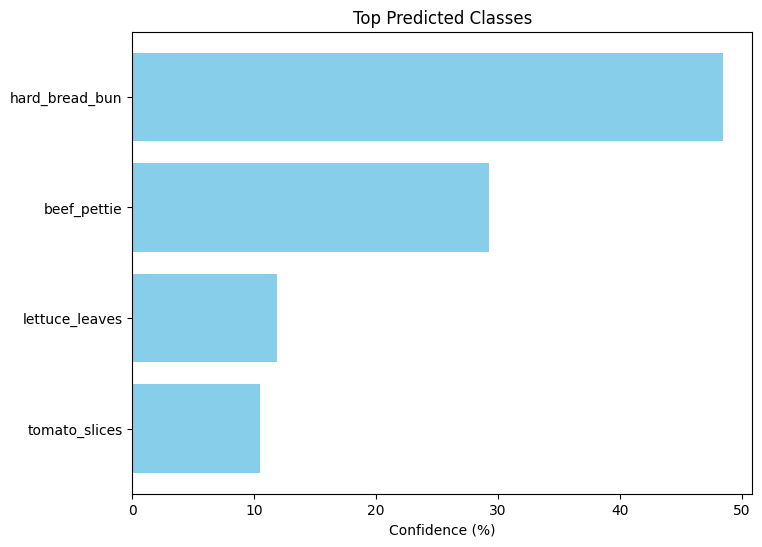

In [22]:
import tkinter as tk
from tkinter import filedialog
from PIL import ImageTk, Image
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
from keras.models import load_model
model = load_model('food_classification_model.h5')

# Define image dimensions
img_width, img_height = 224, 224

# Global variable to hold the image reference
image_ref = None

def classify_image(image_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image) / 255.0  # Rescale image to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    predictions = model.predict(image)[0]
    return predictions

class_indices = {0: 'beef_pettie', 1: 'hard_bread_bun', 2: 'lettuce_leaves', 3: 'tomato_slices'}

def import_image():
    global image_ref
    file_path = filedialog.askopenfilename()
    image = Image.open(file_path)
    image = image.resize((300, 300))
    photo = ImageTk.PhotoImage(image)
    label.config(image=photo)
    label.image = photo  # Keep a reference to prevent garbage collection
    image_ref = photo    # Update the global variable
    predictions = classify_image(file_path)
    top_classes = np.argsort(predictions)[::-1][:5]
    class_labels = [class_indices[idx] for idx in top_classes]
    confidences = [predictions[idx] * 100 for idx in top_classes]
    plot_predictions(class_labels, confidences)


def plot_predictions(class_labels, confidences):
    plt.figure(figsize=(8, 6))
    plt.barh(class_labels, confidences, color='skyblue')
    plt.xlabel('Confidence (%)')
    plt.title('Top Predicted Classes')
    plt.gca().invert_yaxis()
    plt.show()

# Create the GUI
root = tk.Tk()
root.title("Food Image Classifier")

button = tk.Button(root, text="Import Image", command=import_image)
button.pack()

label = tk.Label(root)
label.pack()

root.mainloop()


In [20]:
import tkinter as tk
from tkinter import filedialog
from PIL import ImageTk, Image, ImageDraw, ImageFont
import numpy as np

# Load the trained model
from keras.models import load_model
model = load_model('food_classification_model.h5')

# Define image dimensions
img_width, img_height = 224, 224

# Global variable to hold the image reference
image_ref = None

# Function to classify the imported image
def classify_image(image_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image) / 255.0  # Rescale image to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    predictions = model.predict(image)[0]
    return predictions

# Function to import an image and display predictions
def import_image():
    global image_ref
    file_path = filedialog.askopenfilename()
    image = Image.open(file_path)
    image = image.resize((300, 300))
    photo = ImageTk.PhotoImage(image)
    label.config(image=photo)
    label.image = photo  # Keep a reference to prevent garbage collection
    image_ref = photo    # Update the global variable
    predictions = classify_image(file_path)
    draw_rectangles(image, predictions)

# Function to detect objects and draw bounding boxes
def detect_objects(image_path):
    image = Image.open(image_path)
    image = image.resize((img_width, img_height))
    image_array = np.array(image)
    predictions = object_detection_model.predict(np.expand_dims(image_array, axis=0))
    draw_bounding_boxes(image, predictions)

# Function to draw bounding boxes and class labels on the image
def draw_bounding_boxes(image, predictions):
    draw = ImageDraw.Draw(image)
    font_size = 12
    font = ImageFont.truetype("arial.ttf", font_size)
    
    for prediction in predictions:
        class_label = prediction['class_label']
        confidence = prediction['confidence']
        bbox = prediction['bounding_box']
        
        # Draw bounding box
        draw.rectangle(bbox, outline='red', width=2)
        
        # Draw class label and confidence
        text = f"{class_label}: {confidence:.2f}%"
        draw.text((bbox[0], bbox[1]), text, fill='red', font=font)
    
    image.show()  # Show the image with overlaid bounding boxes and class labels

# Function to import an image and detect objects
def import_image():
    file_path = filedialog.askopenfilename()
    detect_objects(file_path)

# Create the GUI
root = tk.Tk()
root.title("Object Detection")

button = tk.Button(root, text="Import Image", command=import_image)
button.pack()

label = tk.Label(root)
label.pack()

root.mainloop()


Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\tkinter\__init__.py", line 1921, in __call__
    return self.func(*args)
  File "C:\Users\saaif\AppData\Local\Temp\ipykernel_28284\3456721594.py", line 68, in import_image
    detect_objects(file_path)
  File "C:\Users\saaif\AppData\Local\Temp\ipykernel_28284\3456721594.py", line 42, in detect_objects
    predictions = object_detection_model.predict(np.expand_dims(image_array, axis=0))
NameError: name 'object_detection_model' is not defined
